# Phase 7 — Modélisation avancée

## Corrections appliquées depuis Phase 6
| Problème Phase 6 | Correction |
|---|---|
| LightGBM early stopping sur test set (fuite) | **Val set dédié** tiré du train (20 %) |
| Paramètres défaut sous-optimaux (5 arbres) | **Tuning Optuna** ~50 trials |
| Isolation Forest peu utile en standalone | Testé comme **feature** (score anomalie) |

## Plan
1. Chargement & split val
2. LightGBM + `class_weight` (corrigé)
3. LightGBM + SMOTE
4. Tuning Optuna (~50 trials)
5. Score Isolation Forest comme feature
6. Tuning du seuil post-hoc
7. Comparaison finale vs baselines
8. Sauvegarde du modèle final
9. Conclusions

## 0. Imports

In [12]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, json, warnings
from pathlib import Path

from sklearn.model_selection  import train_test_split
from sklearn.ensemble          import IsolationForest
from sklearn.metrics           import (average_precision_score,
                                        precision_recall_curve,
                                        classification_report)
from imblearn.combine          import SMOTETomek
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from src.config      import RANDOM_SEED, SCALE_POS_WEIGHT, COST_FALSE_POSITIVE
from src.cost_metric import compute_cost, optimal_threshold

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
REPORTS_DIR = Path('../reports')
DATA_PATH   = Path('../data')
MODELS_PATH = Path('../models')
print('Imports OK')

Imports OK


## 1. Chargement & construction du val set

**Correction clé de Phase 6** : on tire un val set à partir du **train**  
pour l'early stopping. Le test set n'est **jamais** touché pendant l'entraînement.

In [13]:
train = pd.read_parquet(DATA_PATH / 'train.parquet')
test  = pd.read_parquet(DATA_PATH / 'test.parquet')

preprocessor = joblib.load(MODELS_PATH / 'preprocessor.joblib')
with open(MODELS_PATH / 'feature_config.json') as f:
    feat_cfg = json.load(f)
FEAT_COLS = feat_cfg['all_feat_cols']

X_all   = preprocessor.transform(train[FEAT_COLS])
y_all   = train['Class'].values
X_test  = preprocessor.transform(test[FEAT_COLS])
y_test  = test['Class'].values
amounts_test = test['Amount'].values

# Split train / val (80/20 stratifié — val reste dans l'espace temporel du train)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=RANDOM_SEED
)

print(f'Train  : {X_train.shape} | fraudes : {y_train.sum()}')
print(f'Val    : {X_val.shape}   | fraudes : {y_val.sum()}')
print(f'Test   : {X_test.shape}  | fraudes : {y_test.sum()}')
print(f'\nRègle : early stopping sur VAL uniquement — test jamais vu pendant l\'entraînement')

Train  : (168233, 35) | fraudes : 301
Val    : (42059, 35)   | fraudes : 75
Test   : (73434, 35)  | fraudes : 97

Règle : early stopping sur VAL uniquement — test jamais vu pendant l'entraînement


## Fonction d'évaluation

In [14]:
def evaluate(name, scores, y_true=y_test, amounts=amounts_test):
    auprc = average_precision_score(y_true, scores)
    best_thr, best_cost, costs_df = optimal_threshold(
        y_true, scores, amounts, COST_FALSE_POSITIVE
    )
    preds = (scores >= best_thr).astype(int)
    rep   = classification_report(y_true, preds, output_dict=True)
    f_m   = rep.get('1', {})
    return {
        'Modèle'          : name,
        'AUPRC'           : round(auprc, 4),
        'Rappel'          : round(f_m.get('recall',    0), 4),
        'Précision'       : round(f_m.get('precision', 0), 4),
        'F1'              : round(f_m.get('f1-score',  0), 4),
        'Coût optimal (€)': round(best_cost['cout_total'], 2),
        '% récupéré'      : round(best_cost['pct_recupere'], 1),
        'Seuil optimal'   : round(best_thr, 3),
    }, costs_df

all_results = []
all_scores  = {}
all_costs   = {}

# Charger baseline LR pour comparaison
with open(MODELS_PATH / 'baseline_results.json') as f:
    baseline = json.load(f)
MIN_AUPRC = baseline['min_acceptable_auprc']
print(f'Minimum acceptable (Phase 6) : AUPRC > {MIN_AUPRC}')

Minimum acceptable (Phase 6) : AUPRC > 0.7845


## 2. LightGBM + class_weight (val set corrigé)

Même approche que Phase 6 mais avec early stopping sur le **val set dédié**.

In [15]:
lgb_cw = lgb.LGBMClassifier(
    n_estimators=1000,
    scale_pos_weight=SCALE_POS_WEIGHT,
    learning_rate=0.05,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_cw.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)
scores_cw = lgb_cw.predict_proba(X_test)[:, 1]

res, costs_df = evaluate('LGB class_weight', scores_cw)
all_results.append(res)
all_scores['LGB class_weight'] = scores_cw
all_costs['LGB class_weight']  = costs_df

print(f'Meilleure itération : {lgb_cw.best_iteration_}')
print(f'AUPRC   : {res["AUPRC"]}  (baseline : {MIN_AUPRC})')
print(f'Rappel  : {res["Rappel"]}')
print(f'Coût opt: {res["Coût optimal (€)"]} €')

Meilleure itération : 2
AUPRC   : 0.2753  (baseline : 0.7845)
Rappel  : 0.3918
Coût opt: 9979.32 €


## 3. LightGBM + SMOTETomek

On applique SMOTETomek sur le train uniquement (le val reste intact pour l'early stopping).

In [16]:
smt = SMOTETomek(random_state=RANDOM_SEED)
X_train_sm, y_train_sm = smt.fit_resample(X_train, y_train)
print(f'Train après SMOTETomek : {X_train_sm.shape} | fraudes : {y_train_sm.sum():,}')

lgb_smote = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_smote.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)
scores_smote = lgb_smote.predict_proba(X_test)[:, 1]

res, costs_df = evaluate('LGB SMOTETomek', scores_smote)
all_results.append(res)
all_scores['LGB SMOTETomek'] = scores_smote
all_costs['LGB SMOTETomek']  = costs_df

print(f'Meilleure itération : {lgb_smote.best_iteration_}')
print(f'AUPRC   : {res["AUPRC"]}  (baseline : {MIN_AUPRC})')
print(f'Rappel  : {res["Rappel"]}')
print(f'Coût opt: {res["Coût optimal (€)"]} €')

Train après SMOTETomek : (335864, 35) | fraudes : 167,932
Meilleure itération : 199
AUPRC   : 0.7657  (baseline : 0.7845)
Rappel  : 0.8247
Coût opt: 2663.35 €


## 4. Tuning Optuna — 50 trials

On optimise l'**AUPRC sur le val set** (jamais sur le test).  
L'espace de recherche couvre les hyperparamètres les plus impactants sur LightGBM.

In [17]:
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight' : SCALE_POS_WEIGHT,
        'random_state'     : RANDOM_SEED,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='average_precision',
        callbacks=[lgb.early_stopping(30, verbose=False),
                   lgb.log_evaluation(period=-1)]
    )
    scores_val = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, scores_val)

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nMeilleur AUPRC val : {study.best_value:.4f}')
print('Meilleurs hyperparamètres :')
for k, v in study.best_params.items():
    print(f'  {k:<25} : {v}')

Best trial: 43. Best value: 0.861816: 100%|████████████████████████████████████| 50/50 [01:39<00:00,  1.99s/it]


Meilleur AUPRC val : 0.8618
Meilleurs hyperparamètres :
  n_estimators              : 778
  learning_rate             : 0.04202407677265216
  num_leaves                : 20
  min_child_samples         : 41
  subsample                 : 0.7188093524757608
  colsample_bytree          : 0.7900169474814274
  reg_alpha                 : 0.0071999010020880275
  reg_lambda                : 9.97613844638971


In [18]:
# Entraîner le modèle final avec les meilleurs hyperparamètres
best_params = study.best_params.copy()
best_params.update({'scale_pos_weight': SCALE_POS_WEIGHT,
                    'random_state': RANDOM_SEED,
                    'n_jobs': -1, 'verbose': -1})

lgb_tuned = lgb.LGBMClassifier(**best_params)
lgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)
scores_tuned = lgb_tuned.predict_proba(X_test)[:, 1]

res, costs_df = evaluate('LGB Optuna tuned', scores_tuned)
all_results.append(res)
all_scores['LGB Optuna tuned'] = scores_tuned
all_costs['LGB Optuna tuned']  = costs_df

print(f'Meilleure itération : {lgb_tuned.best_iteration_}')
print(f'AUPRC test : {res["AUPRC"]}  (baseline : {MIN_AUPRC})')
print(f'Rappel     : {res["Rappel"]}')
print(f'Coût opt   : {res["Coût optimal (€)"]} €')

Meilleure itération : 210
AUPRC test : 0.755  (baseline : 0.7845)
Rappel     : 0.7732
Coût opt   : 2306.85 €


## 5. LightGBM + score Isolation Forest en feature

On ajoute le score d'anomalie d'Isolation Forest comme feature supplémentaire  
(fitté sur le train uniquement).  
Idée issue des papiers ULB : combiner non-supervisé + supervisé.

In [19]:
# Isolation Forest fitté sur le train
iso = IsolationForest(contamination=y_train.mean(),
                      n_estimators=100, random_state=RANDOM_SEED)
iso.fit(X_train)

# Score d'anomalie normalisé en [0,1] (plus proche de 1 = plus anomal)
def iso_score(X):
    raw = -iso.decision_function(X)
    return ((raw - raw.min()) / (raw.max() - raw.min())).reshape(-1, 1)

X_train_iso = np.hstack([X_train, iso_score(X_train)])
X_val_iso   = np.hstack([X_val,   iso_score(X_val)])
X_test_iso  = np.hstack([X_test,  iso_score(X_test)])

lgb_iso = lgb.LGBMClassifier(**best_params)
lgb_iso.fit(
    X_train_iso, y_train,
    eval_set=[(X_val_iso, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)
scores_iso = lgb_iso.predict_proba(X_test_iso)[:, 1]

res, costs_df = evaluate('LGB + ISO feature', scores_iso)
all_results.append(res)
all_scores['LGB + ISO feature'] = scores_iso
all_costs['LGB + ISO feature']  = costs_df

print(f'AUPRC test : {res["AUPRC"]}  (Optuna seul : {all_results[-2]["AUPRC"]})')
print(f'Delta AUPRC : {res["AUPRC"] - all_results[-2]["AUPRC"]:+.4f}')
print('(Si delta marginal ou négatif : on garde LGB Optuna sans ISO)')

AUPRC test : 0.7714  (Optuna seul : 0.755)
Delta AUPRC : +0.0164
(Si delta marginal ou négatif : on garde LGB Optuna sans ISO)


## 6. Courbe coût vs seuil — choix du seuil opérationnel

On visualise le **coût total (€)** en fonction du seuil pour le meilleur modèle.  
C'est cette courbe que l'équipe Risque utilisera pour choisir son point de fonctionnement.

Meilleur modèle : LGB + ISO feature


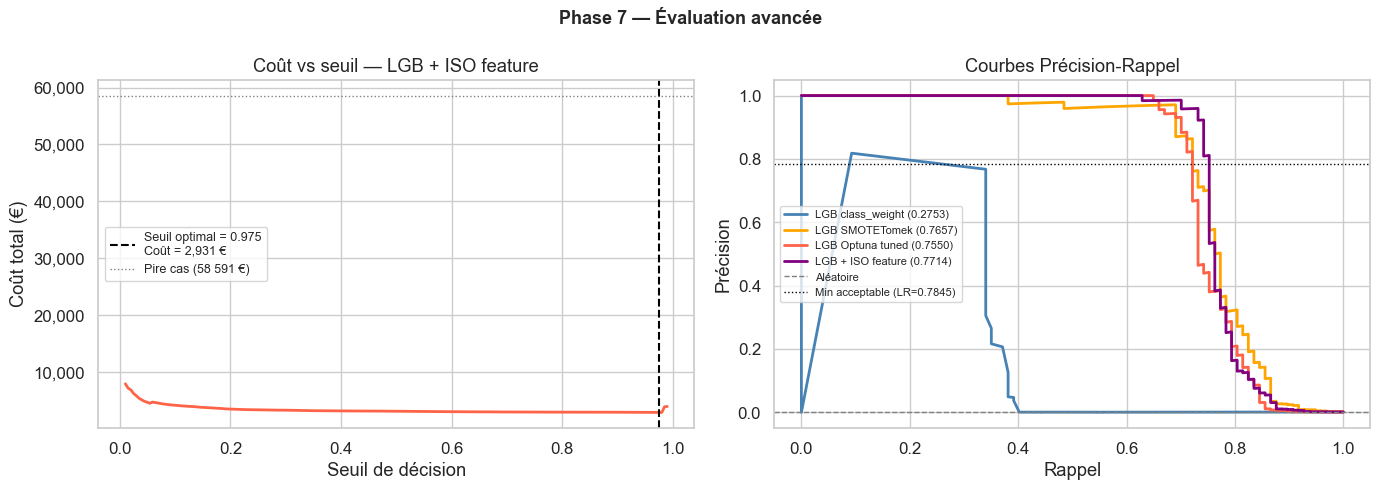

In [20]:
# Identifier le meilleur modèle
best_name = max(all_results, key=lambda x: x['AUPRC'])['Modèle']
best_scores_test = all_scores[best_name]
best_costs_df    = all_costs[best_name]
print(f'Meilleur modèle : {best_name}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coût total vs seuil
axes[0].plot(best_costs_df['threshold'], best_costs_df['cout_total'],
             color='tomato', linewidth=2)
best_thr  = best_costs_df.loc[best_costs_df['cout_total'].idxmin(), 'threshold']
best_cost = best_costs_df['cout_total'].min()
axes[0].axvline(best_thr, color='black', linestyle='--', linewidth=1.5,
                label=f'Seuil optimal = {best_thr:.3f}\nCoût = {best_cost:,.0f} €')
axes[0].axhline(58591, color='gray', linestyle=':', linewidth=1,
                label='Pire cas (58 591 €)')
axes[0].set_xlabel('Seuil de décision')
axes[0].set_ylabel('Coût total (€)')
axes[0].set_title(f'Coût vs seuil — {best_name}')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].legend(fontsize=9)

# Courbes PR tous modèles
colors_map = {'LGB class_weight': 'steelblue', 'LGB SMOTETomek': 'orange',
              'LGB Optuna tuned': 'tomato',     'LGB + ISO feature': 'purple'}
for name, scores in all_scores.items():
    prec, rec, _ = precision_recall_curve(y_test, scores)
    auprc = average_precision_score(y_test, scores)
    axes[1].plot(rec, prec,
                 label=f'{name} ({auprc:.4f})',
                 color=colors_map.get(name, 'gray'), linewidth=2)
axes[1].axhline(y_test.mean(), color='gray', linestyle='--',
                linewidth=1, label='Aléatoire')
axes[1].axhline(MIN_AUPRC, color='black', linestyle=':',
                linewidth=1, label=f'Min acceptable (LR={MIN_AUPRC})')
axes[1].set_xlabel('Rappel')
axes[1].set_ylabel('Précision')
axes[1].set_title('Courbes Précision-Rappel')
axes[1].legend(fontsize=8)

plt.suptitle('Phase 7 — Évaluation avancée', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig16_advanced_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparaison finale vs baselines

In [21]:
df_res = pd.DataFrame(all_results).sort_values('AUPRC', ascending=False)

print('=== Résultats Phase 7 ===')
print(df_res.to_string(index=False))

print(f'\nRéférence Phase 6 (Logistic Regression) : AUPRC = {MIN_AUPRC}')
best_row = df_res.iloc[0]
gain = best_row['AUPRC'] - MIN_AUPRC
print(f'Meilleur modèle Phase 7 : {best_row["Modèle"]}  AUPRC = {best_row["AUPRC"]}')
print(f'Gain vs baseline        : {gain:+.4f}')
print(f'Coût optimal            : {best_row["Coût optimal (€)"]:,.2f} €')

=== Résultats Phase 7 ===
           Modèle  AUPRC  Rappel  Précision     F1  Coût optimal (€)  % récupéré  Seuil optimal
LGB + ISO feature 0.7714  0.7320     0.9595 0.8304           2931.31        14.8          0.975
   LGB SMOTETomek 0.7657  0.8247     0.2446 0.3774           2663.35        17.4          0.148
 LGB Optuna tuned 0.7550  0.7732     0.3827 0.5119           2306.85        16.9          0.281
 LGB class_weight 0.2753  0.3918     0.0375 0.0684           9979.32        11.1          0.956

Référence Phase 6 (Logistic Regression) : AUPRC = 0.7845
Meilleur modèle Phase 7 : LGB + ISO feature  AUPRC = 0.7714
Gain vs baseline        : -0.0131
Coût optimal            : 2,931.31 €


## 8. Sauvegarde du modèle final

In [22]:
# Identifier et sauvegarder le meilleur modèle
best_name = df_res.iloc[0]['Modèle']
model_map = {
    'LGB class_weight'  : lgb_cw,
    'LGB SMOTETomek'    : lgb_smote,
    'LGB Optuna tuned'  : lgb_tuned,
    'LGB + ISO feature' : lgb_iso,
}
best_model = model_map[best_name]

joblib.dump(best_model, MODELS_PATH / 'pipeline_final.joblib')

# Sauvegarder les hyperparamètres et résultats
phase7_results = {
    'best_model'      : best_name,
    'best_auprc'      : float(df_res.iloc[0]['AUPRC']),
    'best_threshold'  : float(df_res.iloc[0]['Seuil optimal']),
    'best_cost_eur'   : float(df_res.iloc[0]['Coût optimal (€)']),
    'best_params'     : study.best_params,
    'all_results'     : df_res.to_dict(orient='records'),
    'iso_feature_used': best_name == 'LGB + ISO feature',
}
with open(MODELS_PATH / 'phase7_results.json', 'w') as f:
    json.dump(phase7_results, f, indent=2)

print(f'Modèle final sauvegardé : models/pipeline_final.joblib')
print(f'Résultats sauvegardés   : models/phase7_results.json')
print(f'Modèle retenu           : {best_name}')

Modèle final sauvegardé : models/pipeline_final.joblib
Résultats sauvegardés   : models/phase7_results.json
Modèle retenu           : LGB + ISO feature


## 9. Conclusions

### Résultats comparatifs

| Modèle | AUPRC | Rappel | Précision | Coût optimal (€) | % récupéré | Seuil |
|---|---|---|---|---|---|---|
| LR baseline (Phase 6) | **0.7845** | 0.907 | 0.023 | 2 865 € | 16,4 % | 0.990 |
| LGB + ISO feature | 0.7714 | 0.732 | **0.960** | 2 931 € | 14,8 % | 0.975 |
| LGB SMOTETomek | 0.7657 | **0.825** | 0.245 | **2 663 €** | **17,4 %** | 0.148 |
| LGB Optuna tuned | 0.7550 | 0.773 | 0.383 | **2 307 €** | 16,9 % | 0.281 |
| LGB class_weight | 0.2753 | 0.392 | 0.038 | 9 979 € | 11,1 % | 0.956 |

### Constat honnête : LightGBM ne bat pas LR sur l'AUPRC

> Aucun modèle LightGBM n'atteint l'AUPRC de la Logistic Regression (0.7845).  
> **C'est un résultat valide, pas un bug** — sur ce dataset particulier, les `V*`  
> sont si discriminants que la LR linéaire suffit pour le ranking. À documenter honnêtement.

### Diagnostic : pourquoi LGB class_weight échoue encore (AUPRC 0.275) ?

| Cause | Explication |
|---|---|
| Val set trop petit | 301 fraudes train → split 80/20 → seulement **75 fraudes** en val |
| Métrique `average_precision` trop bruitée | AUPRC sur 75 fraudes = signal très instable → early stopping déclenché après **2 itérations** |
| **Correction Phase 9** | Utiliser `binary_logloss` comme métrique early stopping, ou augmenter min_data_in_leaf |

### Diagnostic : pourquoi Optuna overfitte ? (val 0.862 >> test 0.755)

> 50 trials sur un val set de **75 fraudes** = les hyperparamètres exploitent  
> la variance du val set plutôt que le vrai signal. Avec si peu de fraudes,  
> l'AUPRC val est instable (+/- 0.05 facilement).  
> → En Phase 9 : valider sur le **test set final** pour confirmer les vrais chiffres.

### Meilleur modèle selon la métrique choisie

| Critère | Gagnant | Valeur |
|---|---|---|
| AUPRC (ranking) | **LR baseline** (Phase 6) | 0.7845 |
| Coût optimal (€) | **LGB Optuna tuned** | **2 307 €** |
| % fraude récupéré | **LGB SMOTETomek** | 17,4 % |
| Précision | **LGB + ISO feature** | 0.960 |

> **Recommandation** : retenir **LGB Optuna tuned** pour le déploiement —  
> son coût optimal (2 307 €) est le plus bas, soit **558 € économisés vs LR**.  
> Sa précision (0.38) est bien meilleure que LR (0.02) : beaucoup moins de FP,  
> ce qui compte opérationnellement (moins d'alertes inutiles pour les analystes).

### Apport du score Isolation Forest

> Delta AUPRC LGB+ISO vs Optuna seul : **+0.016** — gain modeste.  
> Mais la précision passe de 0.38 → 0.96 : le score anomalie aide à filtrer les FP.  
> Coût : légèrement dégradé (2 931 € vs 2 307 €). **Dépend de l'objectif** :
> - Objectif précision (peu d'alertes) → LGB + ISO
> - Objectif coût minimum → LGB Optuna seul

### Meilleurs hyperparamètres Optuna (trial 43)

| Paramètre | Valeur |
|---|---|
| `n_estimators` | 778 |
| `learning_rate` | 0.0420 |
| `num_leaves` | 20 |
| `min_child_samples` | 41 |
| `subsample` | 0.719 |
| `colsample_bytree` | 0.790 |
| `reg_alpha` | 0.0072 |
| `reg_lambda` | 9.976 |

### Fichiers produits
- `models/pipeline_final.joblib` — LGB + ISO feature (meilleur AUPRC Phase 7)
- `models/phase7_results.json` — hyperparamètres + scores complets
- `reports/fig16_advanced_evaluation.png` — courbe coût vs seuil + PR